# CNN 1D - Cadre methodologique modulaire

Ce notebook applique un cadre methodologique reproductible et modulaire avec un modele CNN 1D.

Il permet de :
- definir des profils (donnees, pretraitement, representation, modele, evaluation),
- executer une pipeline coherente,
- produire une fiche modele avec metriques et sorties graphiques.

In [1]:
import os
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import ParameterGrid

from pipeline.extract import add_target, load_csv_features, load_and_resample_features
from pipeline.pretraitement import (
    apply_preprocess,
    apply_target_discretization,
    prepare_splits_and_impute,
)
from pipeline.visu_pretraitement import plot_feature_report, plot_preprocessing_report, plot_split_report
from pipeline.models import fit_final_model, run_hyperparam_search
from pipeline.evaluation import (
    evaluate_by_subject,
    evaluate_robustness,
    evaluate_test_set,
    plot_feature_importance,
    plot_pca_if_classification,
)
from pipeline.reporting import build_model_card, export_visual_report

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

print(f"Seed globale: {SEED}")

I0000 00:00:1778856374.399319  383933 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778856385.606730  383933 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778856399.796986  383933 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Seed globale: 42


## 1) Profils modulaires

In [2]:
# Ajuster ces profils pour chaque experience
# Template source: pipeline/config.md (markdown a copier-coller)

DATA_PROFILE = {
    "source": "csv",
    "file_path": r"../data/Données brutes/DataPhase1_time_short.csv",
    "subject_id_col": "Participant",
    "time_col": "Time",
}

PREPROCESS_PROFILE = {
    "clip_quantiles": [0.01, 0.99],   # clip sur les features
    "imputation_strategy": "median",
    "drop_low_information_features": True,
    "min_valid_features": 1,
    "normalization": "standard",  # None / "standard" / "minmax"
    # Decoupage frequentiel Lomb-Scargle (Hz)
    "frequency_sampling_hz": [0.1],
    "time_col": "time",
    "time_unit": "s",
    "subject_id_col": "subject_id",
    # Colonnes a exclure des features (insensible a la casse)
    "exclude_features": ["minute", "time", "sampling_hz", "row_id", "Left Pupil Diameter", "Right Pupil Diameter"],
    # Colonnes aggrégées
    "column_aggregations": {
        "Pupil diameter AVG": {
            "columns": ["Left Pupil Diameter", "Right Pupil Diameter"],
            "strategy": "mean"
        },
    },
    # include_features : "all" ou liste de colonnes a inclure
    "include_features": [
        "HMDPosX",
        "HMDPosY",
        "HMDPosZ",
        "RotX",
        "RotY",
        "RotZ",
        "Pupil diameter AVG",
        "X gaze direction",
        "Y gaze direction",
        "isBoat",
        "X World Position",
        "Y World Position"
    ]
}

TARGET_PROFILE = {
    "source": "xlsx",
    "xlsx_path": r"../data/Questionnaires/FMS1_org.xlsx",
    "sheet_name": "Feuil1",
    "subject_id_col": "Sujet",
    "target_mode": "per_minute",
    "minute_columns": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
    "minute_col": "minute",
    "clip_quantiles": None,           # clip sur la cible avant discretisation (ex: [0.01, 0.99])
    "discretize": {                   # None pour regression
        "bins":   [0, 5, 10, 20],
        "labels": ["low", "medium", "high"],
    },
}

MODEL_PROFILE = {
    "model_type": "cnn_1d",        # cnn_1d / inception_time / bilstm / cnn_lstm / random_forest / xgboost
    "task_type": "classification",  # classification / regression
    "split_method": "random",        # group / random
    "test_size": 0.20,
    "val_size": 0.20,
    "class_weight": "balanced",
    "random_state": SEED,
}

EVAL_PROFILE = {
    "robustness_noise_std": 0.01,
    "robustness_repeats": 5,
}

OUTPUT_PROFILE = {
    "output_dir": r"../data/outputs/cnn_1d_modulaire",
    "save_model_card": True,
    "save_visual_report": True,
    "visual_report_format": "both",  # pdf / png / both
    "visual_report_name": "visual_report_cnn_1d",
    # "all" pour tout, ou une liste explicite de fonctions
    "visual_report_functions": [
        "visual_cover_page",
        "visual_split_report",
        "visual_missing_values_bar",
        "visual_correlation_pages",
        "visual_violin_pages",
        "visual_clipping_boxplots",
    ],
    "max_corr_features": 24,
    "max_violin_features": 48,
    "violin_features_per_page": 6,
    # Texte libre presente sur la page de garde du rapport visuel (optionnel)
    "hypothesis": (
        """
            hypothese : les dynamiques temporelles reechantillonnees en 0.1 Hz
            ameliorent la prediction du malaise cybersickness.
        """
    ),
}

print("Profils charges depuis la cellule notebook (template config.py)")
print("Data source :", DATA_PROFILE["source"])
print("Modele :", MODEL_PROFILE["model_type"])
print("Tache :", MODEL_PROFILE["task_type"])
print("Target source :", TARGET_PROFILE["source"])
print("Mode cible :", TARGET_PROFILE.get("target_mode", "n/a"))
print("Normalisation :", PREPROCESS_PROFILE.get("normalization") or "aucune")
print("Frequency sampling (Hz) :", PREPROCESS_PROFILE.get("frequency_sampling_hz"))

Profils charges depuis la cellule notebook (template config.py)
Data source : csv
Modele : cnn_1d
Tache : classification
Target source : xlsx
Mode cible : per_minute
Normalisation : standard
Frequency sampling (Hz) : [0.1]


## 3) Construction de representation (Approche A ou B)

In [3]:

if PREPROCESS_PROFILE.get("frequency_sampling_hz") is not None:
    print("Frequency sampling sera applique sur les donnees brutes (avant ajout de la cible).")
    features_df = load_and_resample_features(DATA_PROFILE, PREPROCESS_PROFILE)
else:
    print("Source CSV detectee: les features sont chargees telles quelles.")
    features_df = load_csv_features(DATA_PROFILE)

print("Shape:", features_df.shape)
display(features_df.head())

Frequency sampling sera applique sur les donnees brutes (avant ajout de la cible).
Shape: (64, 22)


,time,HMDPosX,HMDPosY,HMDPosZ,RotX,RotY,RotZ,Suggested Rotation X,Suggested Rotation Y,Suggested Rotation Z,...,X gaze direction,Y gaze direction,Confidence,isBoat,X World Position,Y World Position,subject_id,sampling_hz,minute,row_id
0,482.734,-0.106347,1.150346,0.561426,-6.389508,-0.828109,0.000667,-1.1469,1.146915,-0.015524,...,-0.034503,-0.459316,0.167662,0.127809,2.682135,-6.239336,am3001,0.1,8,0
1,492.734,-0.106347,1.150346,0.561426,-6.389508,-0.828109,0.000667,-1.1469,1.146915,-0.015524,...,-0.034503,-0.459316,0.167662,0.127809,2.682135,-6.239336,am3001,0.1,8,1
2,502.734,-0.106347,1.150346,0.561426,-6.389508,-0.828109,0.000667,-1.1469,1.146915,-0.015524,...,-0.034503,-0.459316,0.167662,0.127809,2.682135,-6.239336,am3001,0.1,8,2
3,512.734,-0.106347,1.150346,0.561426,-6.389508,-0.828109,0.000667,-1.1469,1.146915,-0.015524,...,-0.034503,-0.459316,0.167662,0.127809,2.682135,-6.239336,am3001,0.1,8,3
4,522.734,-0.106347,1.150346,0.561426,-6.389508,-0.828109,0.000667,-1.1469,1.146915,-0.015524,...,-0.034503,-0.459316,0.167662,0.127809,2.682135,-6.239336,am3001,0.1,8,4


## 4) Integration de la cible

In [4]:
dataset_df = add_target(features_df, TARGET_PROFILE)

print("Dataset avec cible:", dataset_df.shape)
print("Apercu colonnes:", dataset_df.columns[:10].tolist())
display(dataset_df.head())

Dataset avec cible: (58, 23)
Apercu colonnes: ['time', 'HMDPosX', 'HMDPosY', 'HMDPosZ', 'RotX', 'RotY', 'RotZ', 'Suggested Rotation X', 'Suggested Rotation Y', 'Suggested Rotation Z']


,time,HMDPosX,HMDPosY,HMDPosZ,RotX,RotY,RotZ,Suggested Rotation X,Suggested Rotation Y,Suggested Rotation Z,...,Y gaze direction,Confidence,isBoat,X World Position,Y World Position,subject_id,sampling_hz,minute,row_id,target
0,482.734,-0.106347,1.150346,0.561426,-6.389508,-0.828109,0.000667,-1.1469,1.146915,-0.015524,...,-0.459316,0.167662,0.127809,2.682135,-6.239336,am3001,0.1,8,0,7.0
1,492.734,-0.106347,1.150346,0.561426,-6.389508,-0.828109,0.000667,-1.1469,1.146915,-0.015524,...,-0.459316,0.167662,0.127809,2.682135,-6.239336,am3001,0.1,8,1,7.0
2,502.734,-0.106347,1.150346,0.561426,-6.389508,-0.828109,0.000667,-1.1469,1.146915,-0.015524,...,-0.459316,0.167662,0.127809,2.682135,-6.239336,am3001,0.1,8,2,7.0
3,512.734,-0.106347,1.150346,0.561426,-6.389508,-0.828109,0.000667,-1.1469,1.146915,-0.015524,...,-0.459316,0.167662,0.127809,2.682135,-6.239336,am3001,0.1,8,3,7.0
4,522.734,-0.106347,1.150346,0.561426,-6.389508,-0.828109,0.000667,-1.1469,1.146915,-0.015524,...,-0.459316,0.167662,0.127809,2.682135,-6.239336,am3001,0.1,8,4,7.0


## 5) Pretraitement, split et preparation

In [5]:

def display_target_info(df, model_profile, target_profile=None, preprocess_profile=None):
    task = model_profile.get("task_type", "regression")
    target = df["target"]

    if task == "classification":
        print("Classes:", sorted(target.dropna().unique().tolist()))
        print("Distribution:")
        print(target.value_counts().sort_index())
    else:
        print("Distribution cible (regression):")
        print(target.describe())

    if target_profile and target_profile.get("clip_quantiles"):
        q_low, q_high = target_profile["clip_quantiles"]
        print(f"\nClip quantiles cible   : [{q_low}, {q_high}]")
    if preprocess_profile and preprocess_profile.get("clip_quantiles"):
        q_low, q_high = preprocess_profile["clip_quantiles"]
        print(f"Clip quantiles features: [{q_low}, {q_high}]")


dataset_df = apply_target_discretization(dataset_df, TARGET_PROFILE)
display_target_info(dataset_df, MODEL_PROFILE, TARGET_PROFILE, PREPROCESS_PROFILE)

raw_df = dataset_df.copy()
dataset_df, feature_cols = apply_preprocess(dataset_df, PREPROCESS_PROFILE)

prepared = prepare_splits_and_impute(
    dataset_df=dataset_df,
    feature_cols=feature_cols,
    preprocess_profile=PREPROCESS_PROFILE,
    model_profile=MODEL_PROFILE,
)

X_train_imp = prepared["X_train_imp"]
X_val_imp = prepared["X_val_imp"]
X_test_imp = prepared["X_test_imp"]
y_train = prepared["y_train"]
y_val = prepared["y_val"]
y_test = prepared["y_test"]
train_idx = prepared["train_idx"]
val_idx = prepared["val_idx"]
test_idx = prepared["test_idx"]
imputer = prepared["imputer"]
scaler = prepared["scaler"]

# Adaptation des tenseurs pour les modeles temporels deep learning.
deep_models = {"cnn_1d", "inception_time", "bilstm", "cnn_lstm"}
if MODEL_PROFILE.get("model_type") in deep_models:
    sequence_length = X_train_imp.shape[1]
    n_features = 1

    X_train_imp = X_train_imp.reshape((-1, sequence_length, n_features))
    X_val_imp = X_val_imp.reshape((-1, sequence_length, n_features))
    X_test_imp = X_test_imp.reshape((-1, sequence_length, n_features))

    MODEL_PROFILE["n_classes"] = int(pd.Series(y_train).nunique()) if MODEL_PROFILE["task_type"] == "classification" else 1
    MODEL_PROFILE["sequence_length"] = int(sequence_length)
    MODEL_PROFILE["n_features"] = int(n_features)

print("\nDataset final:", dataset_df.shape)
print("Nombre de features:", len(feature_cols))
print("Split sizes -> train/val/test:", len(train_idx), len(val_idx), len(test_idx))
if scaler is not None:
    print("Normalisation appliquee:", type(scaler).__name__)
if MODEL_PROFILE.get("model_type") in deep_models:
    print("Shape train pour deep model:", X_train_imp.shape)

display(dataset_df.head())


Classes: ['low', 'medium']
Distribution:
target
low        6
medium    52
high       0
Name: count, dtype: int64
Clip quantiles features: [0.01, 0.99]

Dataset final: (58, 24)
Nombre de features: 12
Split sizes -> train/val/test: 34 12 12
Normalisation appliquee: StandardScaler
Shape train pour deep model: (34, 12, 1)


,time,HMDPosX,HMDPosY,HMDPosZ,RotX,RotY,RotZ,Suggested Rotation X,Suggested Rotation Y,Suggested Rotation Z,...,Confidence,isBoat,X World Position,Y World Position,subject_id,sampling_hz,minute,row_id,target,Pupil diameter AVG
0,482.734,-0.106347,1.150346,0.561426,-6.389508,-0.828109,0.000667,-1.1469,1.146915,-0.015524,...,0.167662,0.127809,2.682135,-6.239336,am3001,0.1,8,0,medium,5.090905
1,492.734,-0.106347,1.150346,0.561426,-6.389508,-0.828109,0.000667,-1.1469,1.146915,-0.015524,...,0.167662,0.127809,2.682135,-6.239336,am3001,0.1,8,1,medium,5.090905
2,502.734,-0.106347,1.150346,0.561426,-6.389508,-0.828109,0.000667,-1.1469,1.146915,-0.015524,...,0.167662,0.127809,2.682135,-6.239336,am3001,0.1,8,2,medium,5.090905
3,512.734,-0.106347,1.150346,0.561426,-6.389508,-0.828109,0.000667,-1.1469,1.146915,-0.015524,...,0.167662,0.127809,2.682135,-6.239336,am3001,0.1,8,3,medium,5.090905
4,522.734,-0.106347,1.150346,0.561426,-6.389508,-0.828109,0.000667,-1.1469,1.146915,-0.015524,...,0.167662,0.127809,2.682135,-6.239336,am3001,0.1,8,4,medium,5.090905


## 5.bis) Visualisation du pretraitement

Shape avant prétraitement : (58, 23)
Shape après prétraitement : (58, 24)
Nombre de sujets exclus : 0
Nombre de features droppées (zero-variance) : 8
Nombre total de NaN avant imputation : 0
Seuils de clipping utilisés : [0.01, 0.99]


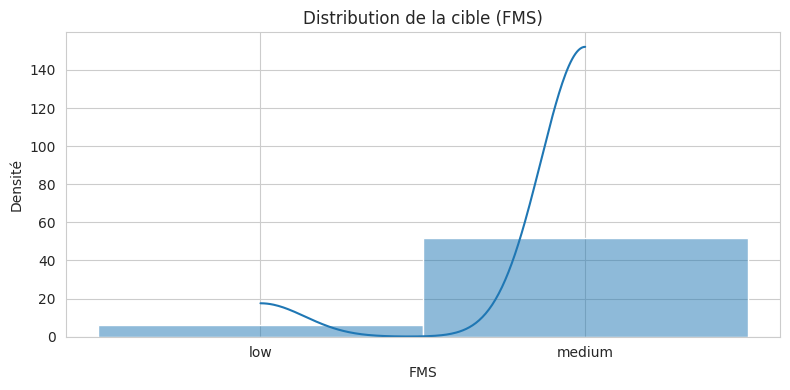

Aucune valeur manquante : barplot ignoré.
Aucune valeur manquante dans les features avant imputation.


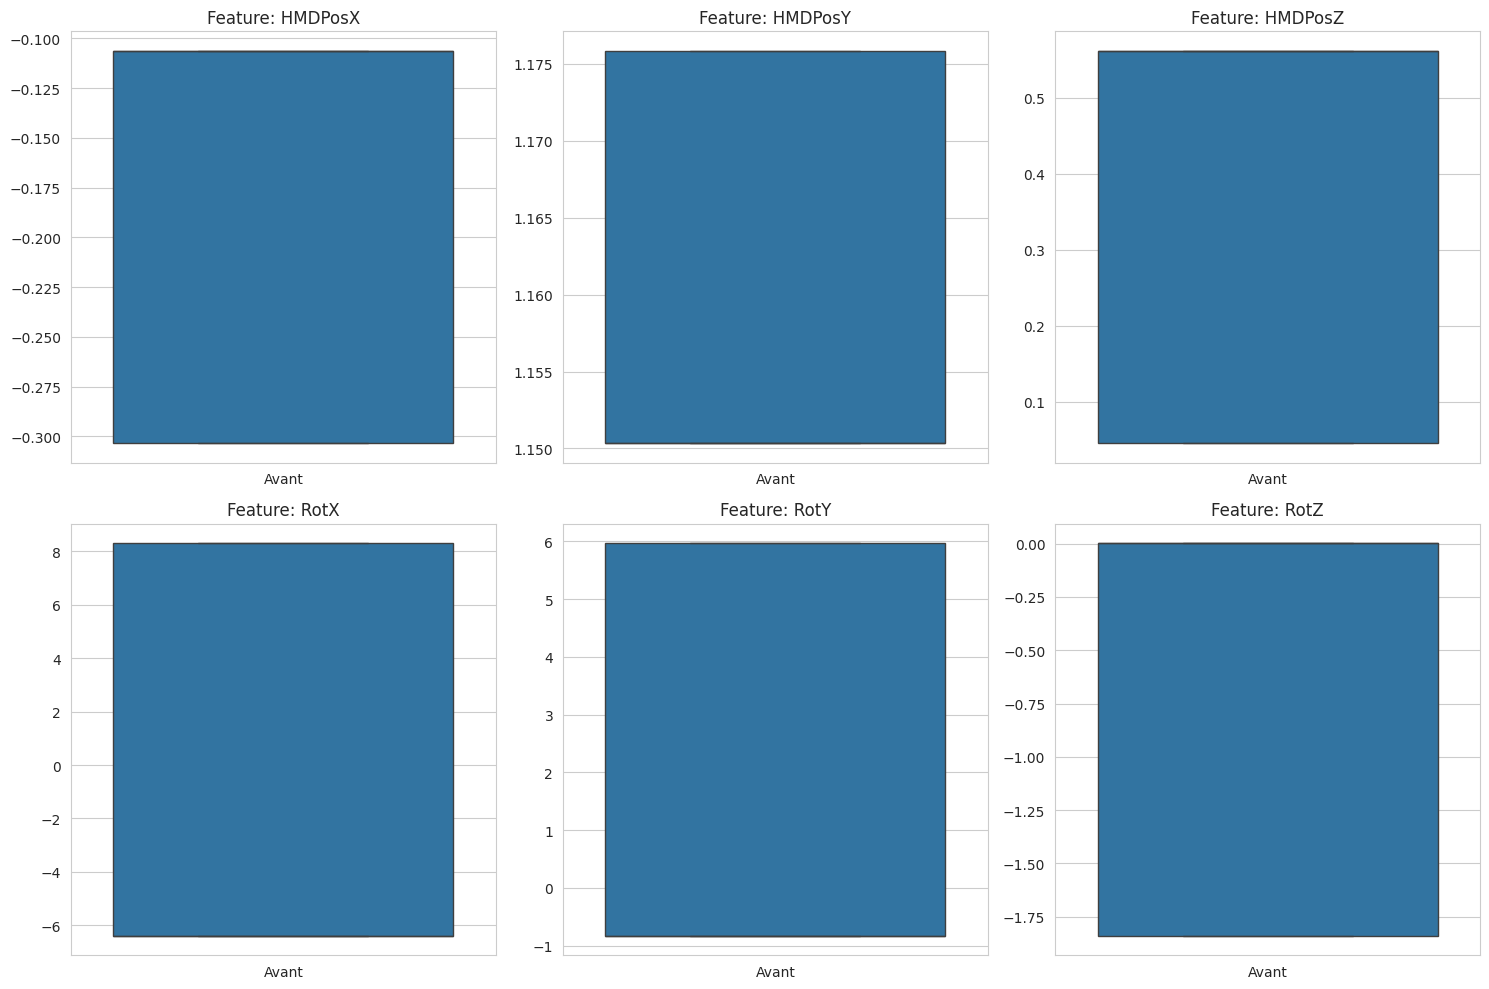

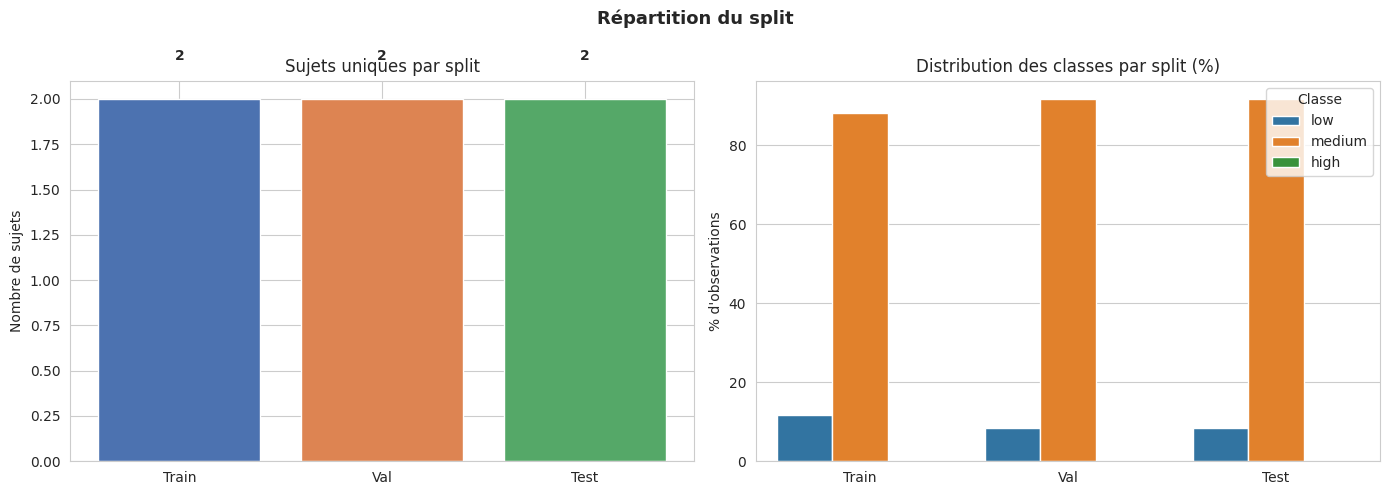

In [6]:
plot_preprocessing_report(raw_df, dataset_df, feature_cols, PREPROCESS_PROFILE)

plot_split_report(dataset_df, train_idx, val_idx, test_idx, MODEL_PROFILE)

## 5.ter) Visualisation des features

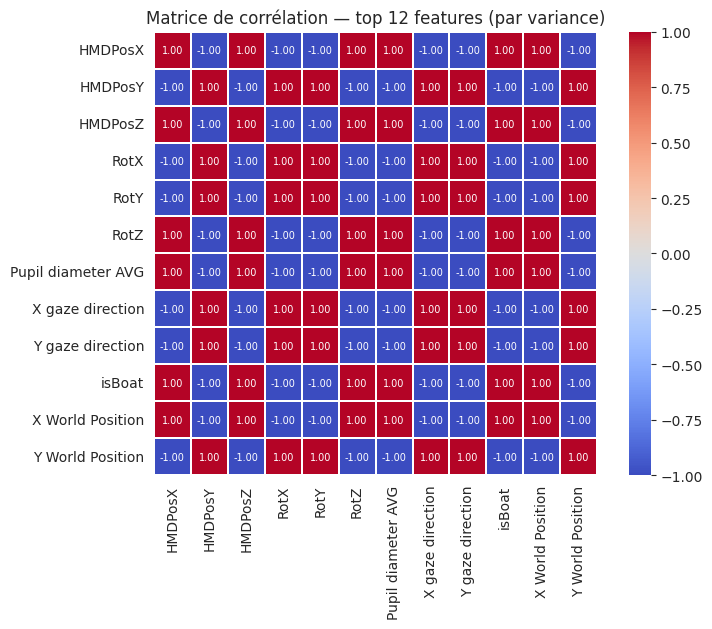

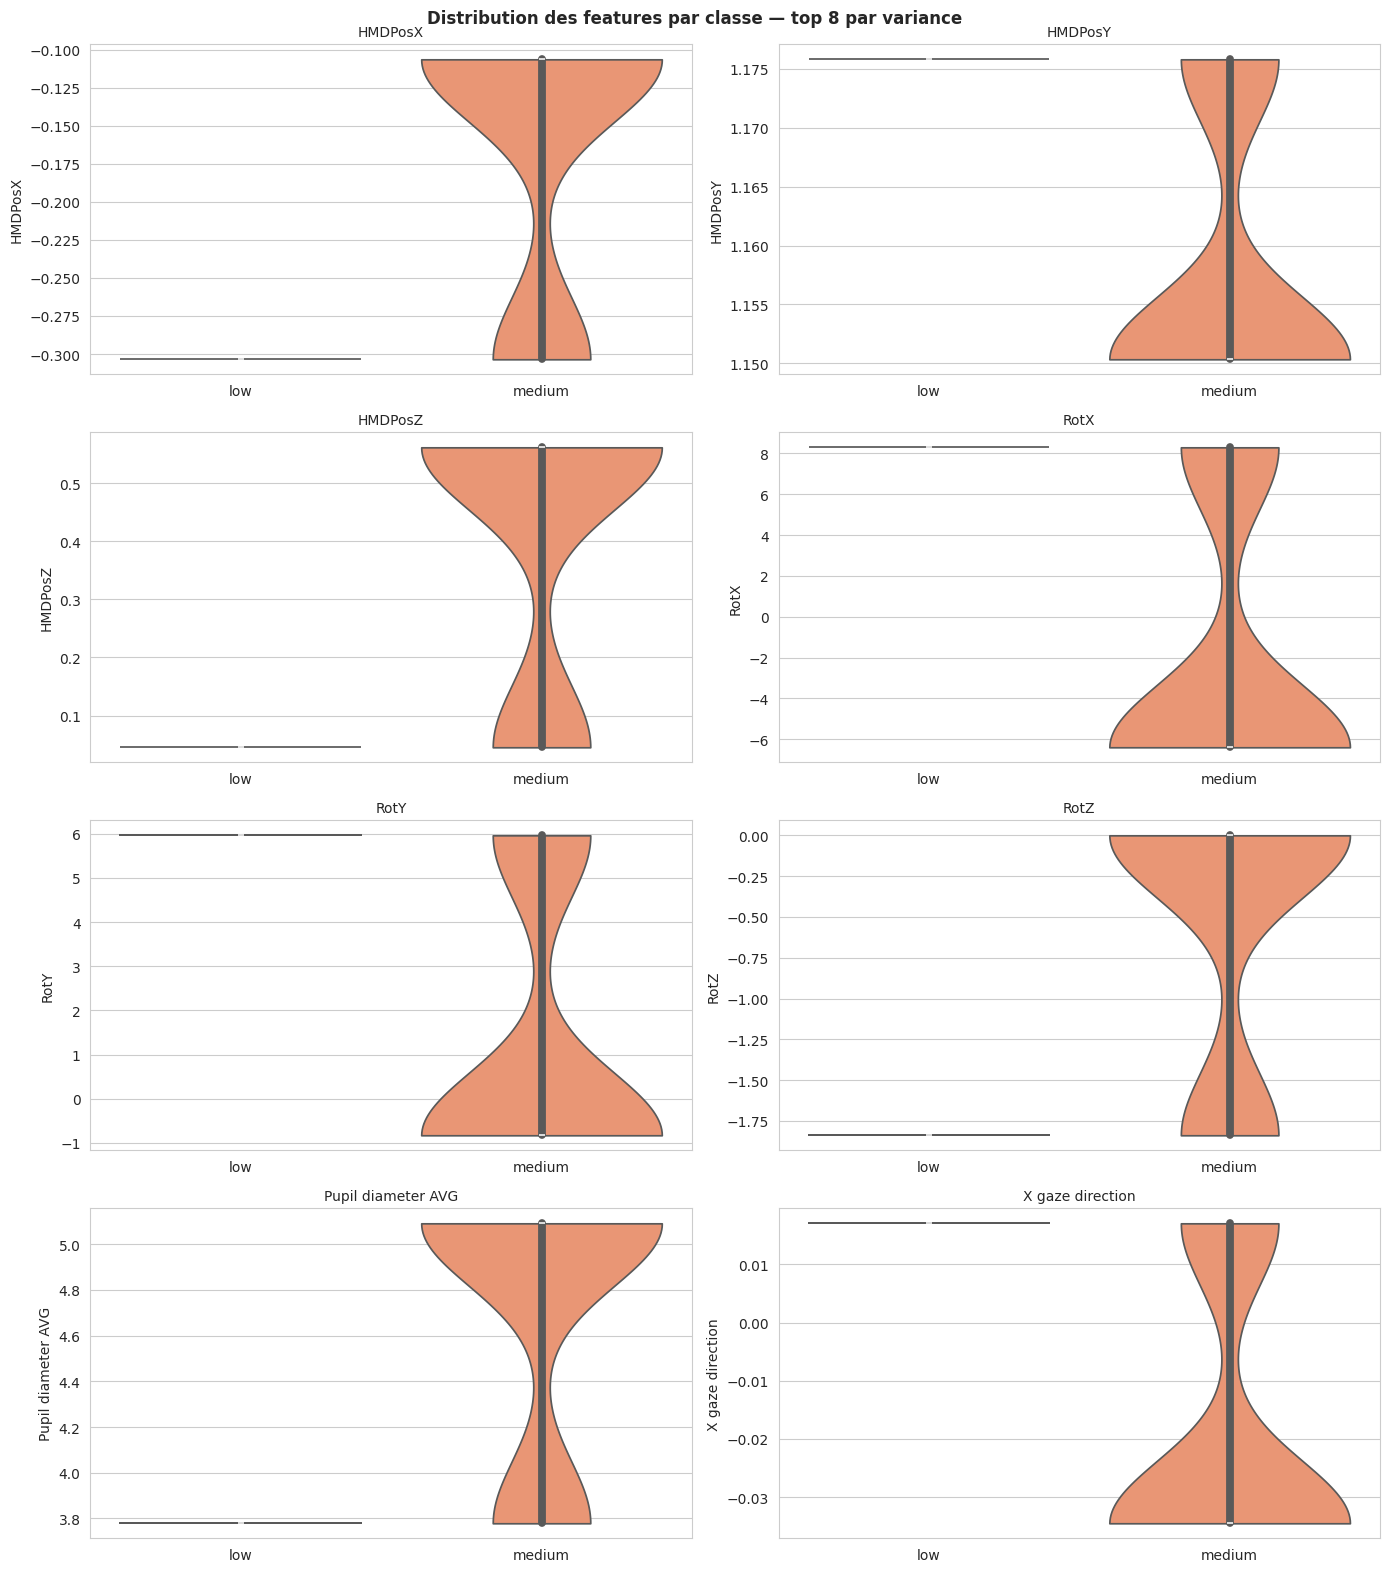

In [7]:
plot_feature_report(dataset_df, feature_cols, MODEL_PROFILE, target_profile=TARGET_PROFILE)

## 6) Optimisation hyperparametres et entrainement

In [8]:
deep_models = {"cnn_1d", "inception_time", "bilstm", "cnn_lstm"}

if MODEL_PROFILE.get("model_type") in deep_models:
    # run_hyperparam_search n'injecte pas les dimensions d'entree; on gere ici la recherche pour les modeles deep.
    from pipeline.models import get_search_space, build_model

    search_space = get_search_space(MODEL_PROFILE["task_type"], model_profile=MODEL_PROFILE)
    rows = []
    best_score = -np.inf
    best_params = None

    for p in ParameterGrid(search_space):
        p = dict(p)
        p["sequence_length"] = MODEL_PROFILE["sequence_length"]
        p["n_features"] = MODEL_PROFILE["n_features"]

        model = build_model(p, MODEL_PROFILE)
        model.fit(X_train_imp, y_train)
        pred_val = model.predict(X_val_imp)

        row = dict(p)
        if MODEL_PROFILE["task_type"] == "classification":
            from sklearn.metrics import accuracy_score, f1_score
            row["val_accuracy"] = accuracy_score(y_val, pred_val)
            row["val_f1_weighted"] = f1_score(y_val, pred_val, average="weighted", zero_division=0)
            score = row["val_f1_weighted"]
        else:
            from sklearn.metrics import mean_squared_error, r2_score
            rmse = float(np.sqrt(mean_squared_error(y_val, pred_val)))
            row["val_rmse"] = rmse
            row["val_r2"] = r2_score(y_val, pred_val)
            score = -rmse

        rows.append(row)
        if score > best_score:
            best_score = score
            best_params = dict(p)

    results_df = pd.DataFrame(rows)
    sort_col = "val_f1_weighted" if MODEL_PROFILE["task_type"] == "classification" else "val_rmse"
    ascending = MODEL_PROFILE["task_type"] != "classification"
    results_df = results_df.sort_values(by=sort_col, ascending=ascending).reset_index(drop=True)

else:
    best_params, results_df = run_hyperparam_search(
        X_train_imp=X_train_imp,
        y_train=y_train,
        X_val_imp=X_val_imp,
        y_val=y_val,
        model_profile=MODEL_PROFILE,
    )

display(results_df.head(10))
print("Best params:", best_params)

final_model = fit_final_model(
    X_train_imp=X_train_imp,
    y_train=y_train,
    X_val_imp=X_val_imp,
    y_val=y_val,
    best_params=best_params,
    model_profile=MODEL_PROFILE,
)

E0000 00:00:1778856420.632171  383933 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
W0000 00:00:1778856430.393397  383933 op_kernel.cc:1834] OP_REQUIRES failed at cast_op.cc:122 : UNIMPLEMENTED: Cast string to float is not supported


UnimplementedError: Graph execution error:

Detected at node compile_loss/sparse_categorical_crossentropy/Cast defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/home/forg0016/MASTER1/cybersickness-early-detection/.venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/home/forg0016/MASTER1/cybersickness-early-detection/.venv/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/home/forg0016/MASTER1/cybersickness-early-detection/.venv/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 758, in start

  File "/home/forg0016/MASTER1/cybersickness-early-detection/.venv/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 211, in start

  File "/usr/lib/python3.12/asyncio/base_events.py", line 645, in run_forever

  File "/usr/lib/python3.12/asyncio/base_events.py", line 1999, in _run_once


## 7) Evaluation, robustesse et visualisations

In [ ]:
pred_test, metrics, classification_text_report = evaluate_test_set(
    final_model=final_model,
    X_test_imp=X_test_imp,
    y_test=y_test,
    model_profile=MODEL_PROFILE,
    target_profile=TARGET_PROFILE,
    show_plots=True,
)

print(pd.Series(metrics))
if classification_text_report is not None:
    print("\nClassification report:")
    print(classification_text_report)

by_subject = evaluate_by_subject(
    dataset_df=dataset_df,
    test_idx=test_idx,
    y_test=y_test,
    pred_test=pred_test,
    model_profile=MODEL_PROFILE,
)
display(by_subject.head(20))

noise_scores = evaluate_robustness(
    final_model=final_model,
    X_test_imp=X_test_imp,
    y_test=y_test,
    model_profile=MODEL_PROFILE,
    eval_profile=EVAL_PROFILE,
    seed=SEED,
    show_plot=True,
)
print("Score robustesse (moyenne):", float(np.mean(noise_scores)))

imp_df = plot_feature_importance(final_model, feature_cols, top_n=15)
if imp_df is not None:
    display(imp_df.head(20))

plot_pca_if_classification(X_test_imp, y_test, MODEL_PROFILE, seed=SEED)

NameError: name 'evaluate_test_set' is not defined

## 8) Fiche modele

In [ ]:
model_card = build_model_card(
    dataset_df=dataset_df,
    feature_cols=feature_cols,
    model_profile=MODEL_PROFILE,
    data_profile=DATA_PROFILE,
    best_params=best_params,
    metrics=metrics,
    noise_scores=noise_scores,
    preprocess_profile=PREPROCESS_PROFILE,
)

display(pd.DataFrame([{"field": k, "value": str(v)} for k, v in model_card.items()]))

export_visual_report(
    dataset_df=dataset_df,
    feature_cols=feature_cols,
    model_profile=MODEL_PROFILE,
    output_profile=OUTPUT_PROFILE,
    train_idx=train_idx,
    val_idx=val_idx,
    test_idx=test_idx,
    target_profile=TARGET_PROFILE,
    raw_df=raw_df,
    preprocess_profile=PREPROCESS_PROFILE
)

,field,value
0,model_name,RandomForest
1,task_type,classification
2,data_source,csv
3,dataset,../data/Indicateurs calculés/FullTimeIndicator...
4,mat_variable,None
5,n_samples,522
6,n_subjects,39
7,n_features,16
8,split_method,group
9,test_size,0.2


{'pages': 8,
 'report_name': 'visual_report_20260505_144514',
 'pdf_path': '../data/outputs/random_forest_modulaire\\visual_report_20260505_144514.pdf',
 'png_dir': '../data/outputs/random_forest_modulaire\\visual_report_20260505_144514_png'}